# Churn Prediction Pipeline
Trains XGBoost, Random Forest, and Logistic Regression models and saves them to disk.

## 1. Imports

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
)

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')

MODELS_DIR = 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Models will be saved to: {MODELS_DIR}/')

c:\Users\adnan\OneDrive\Desktop\Projects\Churn_ modelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Models will be saved to: saved_models/


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('Customer Churn.csv')
print(f'Shape: {df.shape}')

target_col = 'Churn'
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categoricals
X = pd.get_dummies(X, drop_first=True)

print(f'Features: {X.shape[1]}')
print(f'Churn rate: {y.mean():.2%}')

Shape: (3150, 14)
Features: 13
Churn rate: 15.71%


## 3. Train / Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# Save test set for use in main script
joblib.dump((X_test, y_test), os.path.join(MODELS_DIR, 'test_data.pkl'))
print('Test data saved.')

Train: 2520 | Test: 630
Test data saved.


## 4. Define Models & Hyperparameter Grids

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_configs = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', solver='liblinear'))
        ]),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l1', 'l2']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_leaf': [2, 5]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        ),
        'params': {
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200]
        }
    }
}
print('Model configs ready.')

Model configs ready.


## 5. Train Models with GridSearchCV & Save

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}

for name, cfg in model_configs.items():
    print(f'Training {name}...')
    grid = GridSearchCV(
        cfg['model'], cfg['params'],
        cv=cv, scoring='f1', n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f'  Best params: {grid.best_params_}')

    # Save individual model
    model_path = os.path.join(MODELS_DIR, f'{name}.pkl')
    joblib.dump(grid.best_estimator_, model_path)
    print(f'  Saved -> {model_path}')

print('\nAll models saved.')

Training LogisticRegression...
  Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
  Saved -> saved_models\LogisticRegression.pkl
Training RandomForest...
  Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
  Saved -> saved_models\RandomForest.pkl
Training XGBoost...
  Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
  Saved -> saved_models\XGBoost.pkl

All models saved.


## 6. Evaluate All Models

In [6]:
metrics_list = []

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results = pd.DataFrame(metrics_list).set_index('Model')
print(results.round(4))

                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                             
LogisticRegression    0.8397     0.4943  0.8788    0.6327   0.9205
RandomForest          0.9714     0.8932  0.9293    0.9109   0.9853
XGBoost               0.9619     0.8378  0.9394    0.8857   0.9927


## 7. Confusion Matrices

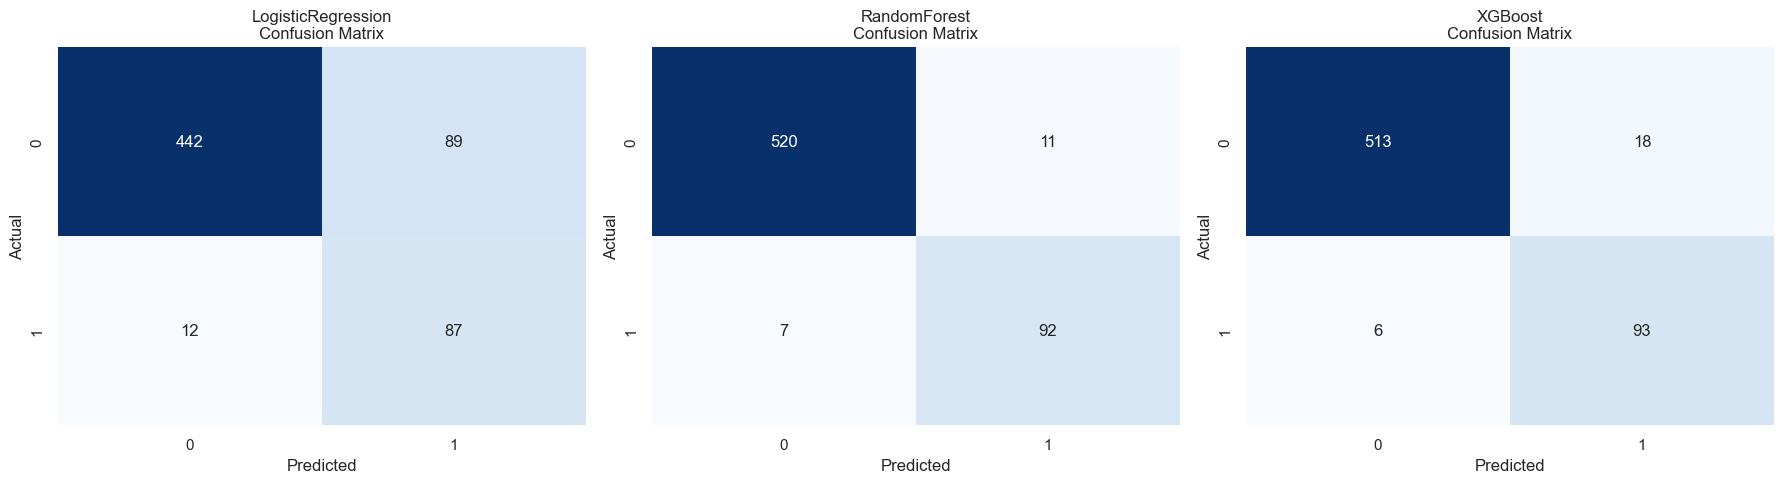

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, best_estimators.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. ROC & Precision-Recall Curves

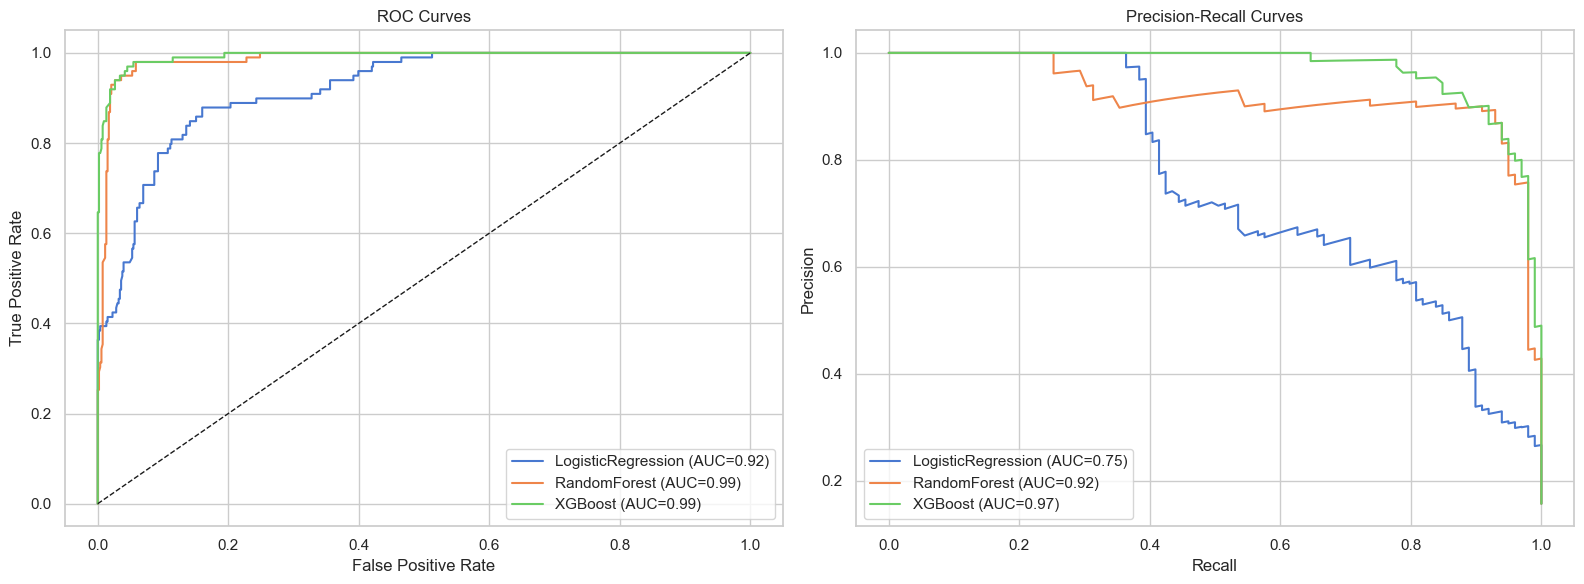

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, model in best_estimators.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(recall, precision, label=f'{name} (AUC={auc(recall, precision):.2f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. SHAP Explanation (Best Model by F1)

Best model: RandomForest


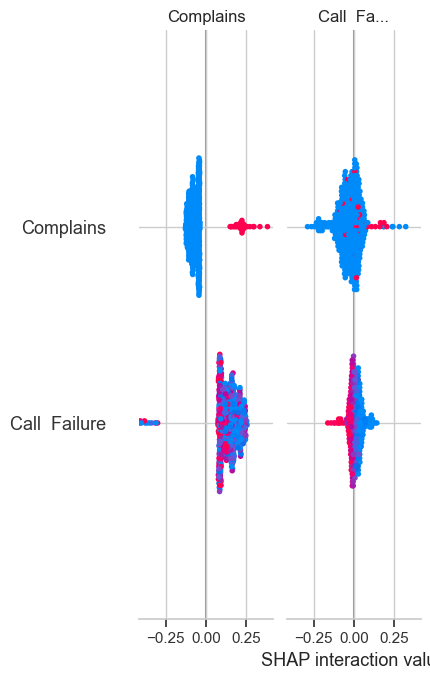

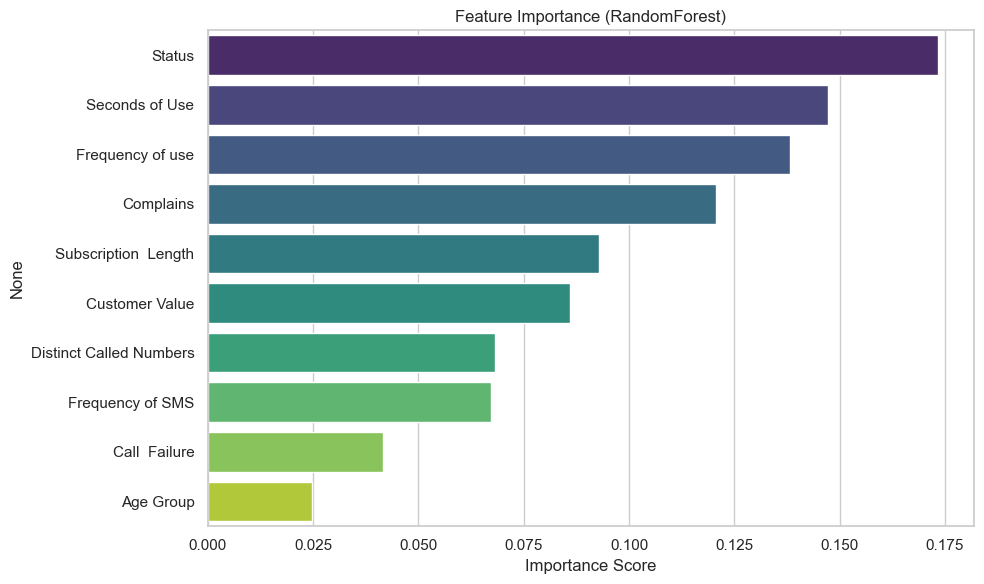

In [9]:
best_model_name = results['F1-Score'].idxmax()
model = best_estimators[best_model_name]
print(f'Best model: {best_model_name}')

if 'Pipeline' in str(type(model)):
    X_scaled = model.named_steps['scaler'].transform(X_test)
    explainer = shap.LinearExplainer(model.named_steps['clf'], X_scaled)
    shap_values = explainer.shap_values(X_scaled)
    shap.summary_plot(shap_values, X_test, show=True)
else:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, show=True)

    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(
            model.feature_importances_, index=X_test.columns
        ).sort_values(ascending=False).head(10)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=importances.values, y=importances.index, palette='viridis')
        plt.title(f'Feature Importance ({best_model_name})')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()